# Komödie oder Tragödie?

Kann ein Klassifikator allein aus dem gesprochenen Text erkennen, ob ein deutsches
Drama eine Komödie oder eine Tragödie ist?

Hausarbeit *Maschinelles Lernen*, DH Trier. Korpus: [GerDraCor](https://dracor.org/ger), CC0.

Läuft von oben nach unten. Abschnitt 1 lädt die Daten (einmalig ein paar Minuten).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import drama
from drama import GENRES

COLOUR = {'comedy': '#b5651d', 'tragedy': '#4a6fa5'}
SEEDS = range(10)

### Was liegt in `drama.py`?

Alles, was nicht zur Argumentation gehört, steht in `drama.py`, damit hier nur die
Analyse steht. Es passiert dort nichts Trickreiches:

| Funktion | tut |
|---|---|
| `get_metadata()` | lädt die Metadatentabelle (774 Zeilen), einmalig, danach aus dem Cache |
| `make_catalog(meta)` | schneidet sie auf die fünf Spalten zu, die ich brauche, und hängt beide Genre-Labels an |
| `download_texts(catalog)` | lädt den gesprochenen Text je Stück in eine eigene Datei |
| `read_texts(catalog)` | liest diese Dateien wieder ein, als Spalte `text` |
| `get_characters(catalog)` | lädt die Personenverzeichnisse (für Abschnitt 7) |
| `count_words(texts)` | baut die Wortliste und zählt: eine Zeile je Stück, eine Spalte je Wort |
| `count_with_words(texts, words)` | zählt mit einer *bestehenden* Wortliste, damit später bewertete Stücke zur Trainingsmatrix passen |
| `split_by_author` / `split_randomly` | die zwei Split-Arten, geben zwei Boolean-Masken zurück |
| `folds_by_author` | dasselbe als 5-fache Kreuzvalidierung |
| `majority_share(labels)` | die Baseline: was man trifft, wenn man immer das häufigere Genre rät |
| `purity`, `to_shares`, `tokenize`, `save` | Kleinkram |

Alles, was heruntergeladen wird, landet in `data/` und wird beim nächsten Lauf
übersprungen. Der erste Durchlauf dauert ein paar Minuten, danach Sekunden.

## 1 · Daten

In [2]:
# the full metadata table: 774 plays, 43 columns. cached after the first run.
meta = drama.get_metadata()

# cut down to play / author / year / subtitle / genre, and attach both labels.
# the catalog is only metadata - no text yet, that comes further down.
catalog = drama.make_catalog(meta)

# GerDraCor keeps growing and has no release numbers, so the git commit is the
# only way to say which state of the corpus these numbers came from. Without it
# "GerDraCor, 774 plays" points at nothing in particular a year from now.
print(drama.corpus_version())
print()
print(catalog['genre_raw'].fillna('(none)').value_counts().to_string())

gerdracor commit 15a666187e4243368f29c6b7b3f4c461ec94a33c
committed   2026-08-04T07:18:22Z
downloaded  2026-08-27

genre_raw
(none)         358
Comedy         241
Tragedy        168
Tragicomedy      7


In [3]:
catalog.head()

,play,author,year,subtitle,genre_raw,dracor,german
0,achat-ein-april-scherz,Achat,1842,Original-Lustspiel in einem Akt,Comedy,comedy,comedy
1,adolph-am-ersten-mai,Adolph,1919,Eine Tragikomödie der Arbeit aus Friedenstagen,NaN,None,None
2,alberti-brot,Alberti,1888,Ein soziales Schauspiel in fünf Akten,NaN,None,None
3,alberti-im-suff,Alberti,1890,Naturalistische Spital-Katastrophe in zwei Vor...,NaN,None,None
4,albrecht-theresgen,Albrecht,1781,"Ein Schauspiel mit Gesang, in fünf Aufzügen",NaN,None,None


In [4]:
# plays per genre, and how many different authors wrote them
for source in ['dracor', 'german']:
    for g in GENRES:
        rows = catalog[catalog[source] == g]
        top5 = rows['author'].value_counts().head(5).sum()
        print(source, g)
        print('   plays  ', len(rows))
        print('   authors', rows['author'].nunique())
        print('   top 5 authors hold', round(100 * top5 / len(rows)), '%')

dracor comedy
   plays   241
   authors 132
   top 5 authors hold 19 %
dracor tragedy
   plays   168
   authors 99
   top 5 authors hold 21 %
german comedy
   plays   200
   authors 112
   top 5 authors hold 22 %
german tragedy
   plays   165
   authors 99
   top 5 authors hold 20 %


Zwei unabhängige Labels: DraCors `normalizedGenre` und meine Lesung des deutschen
Untertitels. Wo sie sich widersprechen, ist interessanter als wo nicht.

In [5]:
both = catalog.dropna(subset=['dracor', 'german'])
disagree = both[both['dracor'] != both['german']]

print('plays with both labels:', len(both))
print('they disagree on      :', len(disagree))
disagree[['play', 'dracor', 'german', 'subtitle']]

plays with both labels: 361
they disagree on      : 3


,play,dracor,german,subtitle
117,castelli-jeitteles-der-schicksalsstrumpf,comedy,tragedy,Tragödie in zwei Akten
525,panizza-das-liebeskonzil,comedy,tragedy,Eine Himmelstragödie in fünf Aufzügen
562,reuter-der-ehrlichen-frau-schlampampe-krankhei...,comedy,tragedy,in einem Lust- und Trauerspiele vorgestellet u...


In [6]:
# LABEL_SOURCE is set in drama.py. 'dracor' uses their normalizedGenre,
# 'german' uses my reading of the subtitle. Switching it and re-running the
# whole notebook is the robustness check.
labelled = catalog[catalog[drama.LABEL_SOURCE].notna()]

# one text file per play. already downloaded files are skipped, so re-running
# this cell costs nothing.
print(drama.download_texts(labelled))

# read those files back in. plays now has everything: metadata plus the text.
plays = drama.read_texts(labelled)
plays['genre'] = plays[drama.LABEL_SOURCE]

genre = plays['genre'].values
length = plays['text'].str.split().str.len()

# 241 of 409 plays are comedies, so answering "comedy" every time already
# scores 0.586. Every accuracy in this notebook is reported against this.
BASELINE = drama.majority_share(genre)

print()
print('plays  ', len(plays))
print('authors', plays['author'].nunique())
print()
print(plays['genre'].value_counts().to_string())
print()
print('shortest play', length.min(), 'words')
print('median       ', int(length.median()), 'words')
print('longest      ', length.max(), 'words')
print('baseline     ', round(BASELINE, 3))

{'downloaded': 0, 'already had': 409, 'failed': 0}

plays   409
authors 192

genre
comedy     241
tragedy    168

shortest play 739 words
median        13058 words
longest       158896 words
baseline      0.589


Was der Klassifikator tatsächlich zu sehen bekommt:

In [7]:
example = plays[plays['play'] == 'lessing-emilia-galotti']
print(example.iloc[0]['play'], '-', example.iloc[0]['genre'])
print()
print(example.iloc[0]['text'][:400])

lessing-emilia-galotti - tragedy

Klagen, nichts als Klagen! Bittschriften, nichts als Bittschriften! – Die traurigen Geschäfte; und man beneidet uns noch! – Das glaub' ich; wenn wir allen helfen könnten: dann wären wir zu beneiden. – Emilia? Eine Emilia? – Aber eine Emilia Bruneschi – nicht Galotti. Nicht Emilia Galotti! – Was will sie, diese Emilia Bruneschi? Viel gefodert; sehr viel. – Doch sie heißt Emilia. Gewährt! Es ist woh


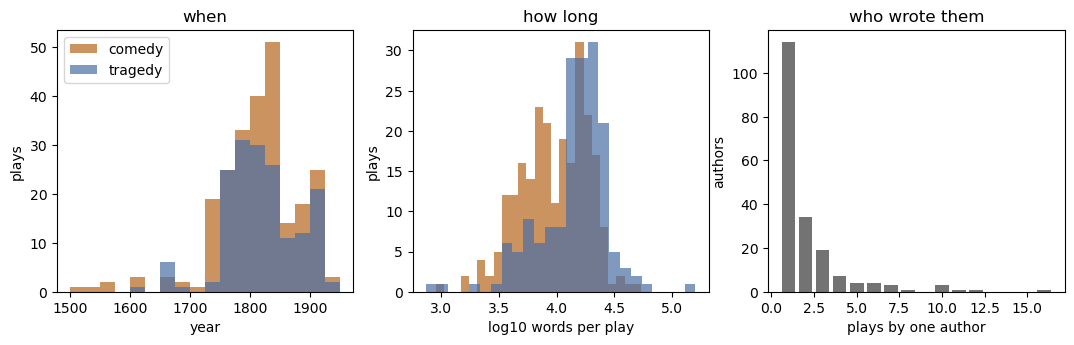

In [8]:
figure, axes = plt.subplots(1, 3, figsize=(13, 3.4))

# when were they written?
year = plays['year'].astype(float)
for g in GENRES:
    axes[0].hist(year[genre == g], bins=np.arange(1500, 1975, 25),
                 alpha=0.7, color=COLOUR[g], label=g)
axes[0].set_xlabel('year')
axes[0].set_ylabel('plays')
axes[0].set_title('when')
axes[0].legend()

# how long are they? log scale, because the range is a factor of 200
for g in GENRES:
    axes[1].hist(np.log10(length[genre == g]), bins=25,
                 alpha=0.7, color=COLOUR[g], label=g)
axes[1].set_xlabel('log10 words per play')
axes[1].set_ylabel('plays')
axes[1].set_title('how long')

# how many plays does one author contribute?
per_author = plays['author'].value_counts().value_counts().sort_index()
axes[2].bar(per_author.index, per_author.values, color='0.45')
axes[2].set_xlabel('plays by one author')
axes[2].set_ylabel('authors')
axes[2].set_title('who wrote them')

drama.save(figure, 'fig0_corpus.png')
plt.show()

In [9]:
# counts is a 409 x 3000 matrix of raw word counts, vocabulary is the word list.
# 3000 words, each appearing in at least 5 plays: fewer and the genre-specific
# vocabulary starts dropping out, more and the extra columns are words from a
# handful of plays that only add noise.
counts, vocabulary = drama.count_words(plays['text'])
print('matrix:', counts.shape[0], 'plays x', counts.shape[1], 'words')
print()

# could one very long play set a whole genre's word distribution by itself?
for g in GENRES:
    mass = counts[genre == g].sum(axis=1)
    biggest = plays[genre == g]['play'].iloc[mass.argmax()]
    print(g, 'longest play is', round(100 * mass.max() / mass.sum(), 1), '% of the genre')
    print('   ', biggest)

matrix: 409 plays x 3000 words

comedy longest play is 2.0 % of the genre
    tieck-prinz-zerbino
tragedy longest play is 4.9 % of the genre
    kraus-die-letzten-tage-der-menschheit


## 2 · Klassifikation

Multinomial Naive Bayes: zwei Wortverteilungen, eine je Genre. Ein Stück bekommt das
Genre, unter dem seine Wortmischung weniger überraschend ist.

Bei *author-disjoint* liegt kein Autor auf beiden Seiten des Splits, bei *random*
schon. Die Differenz zeigt, wie viel von der Genre-Erkennung eigentlich
Autorerkennung ist.

In [10]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix


def comedy_lean(model):
    # feature_log_prob_ holds one row of word log-probabilities per genre, in the
    # order of model.classes_. Subtracting the two rows gives, for every word, how
    # much more likely it is in a comedy. Used again in sections 5, 6 and 8.
    comedy = list(model.classes_).index('comedy')
    tragedy = list(model.classes_).index('tragedy')
    return model.feature_log_prob_[comedy] - model.feature_log_prob_[tragedy]

In [11]:
results = []
matrices = {}
matrices['author-disjoint'] = np.zeros((2, 2), int)
matrices['random'] = np.zeros((2, 2), int)

splitters = [('author-disjoint', drama.split_by_author),
             ('random', drama.split_randomly)]

for seed in SEEDS:
    for kind, split in splitters:
        # both are boolean masks over plays. split_by_author keeps whole
        # playwrights on one side: Kotzebue has 16 plays here, and under a
        # random split the model could recognise him instead of the genre.
        train, test = split(plays, seed=seed)

        model = MultinomialNB()
        model.fit(counts[train], genre[train])
        predicted = model.predict(counts[test])

        # labels=GENRES fixes the row and column order, otherwise sklearn sorts
        # them itself and the matrices would not add up consistently
        matrices[kind] = matrices[kind] + confusion_matrix(genre[test], predicted,
                                                           labels=GENRES)

        # the baseline is stored per row, not taken from the corpus as a whole,
        # because the ablations further down drop plays and shift the class
        # balance. Comparing raw accuracies across them would be wrong.
        results.append({'model': 'naive bayes',
                        'split': kind,
                        'seed': seed,
                        'baseline': drama.majority_share(genre[test]),
                        'accuracy': accuracy_score(genre[test], predicted),
                        'macro f1': f1_score(genre[test], predicted, average='macro')})

scores = pd.DataFrame(results)
scores.groupby('split')[['accuracy', 'macro f1']].agg(['mean', 'std']).round(3)

accuracy        macro f1       
                    mean    std     mean    std
split                                          
author-disjoint    0.843  0.034    0.835  0.036
random             0.827  0.018    0.823  0.018

In [12]:
# read precision and recall straight off the pooled matrix, which holds all
# ~1240 test predictions rather than one lucky split
for kind in ['author-disjoint', 'random']:
    table = matrices[kind]
    print(kind)
    print(pd.DataFrame(table, index=GENRES, columns=GENRES).to_string())

    for i in range(2):
        hit = table[i, i]
        precision = hit / table[:, i].sum()      # column i = everything predicted i
        recall = hit / table[i, :].sum()         # row i = everything truly i
        f1 = 2 * precision * recall / (precision + recall)
        print('  ', GENRES[i],
              'P', round(precision, 3),
              'R', round(recall, 3),
              'F1', round(f1, 3))
    print()

author-disjoint
         comedy  tragedy
comedy      624      106
tragedy      90      427
   comedy P 0.874 R 0.855 F1 0.864
   tragedy P 0.801 R 0.826 F1 0.813

random
         comedy  tragedy
comedy      593      105
tragedy     106      416
   comedy P 0.848 R 0.85 F1 0.849
   tragedy P 0.798 R 0.797 F1 0.798



In [13]:
# The split comparison above only means something if a random split really did
# put the same author on both sides. The median author here wrote one play, so
# it might already be nearly author-disjoint by accident - in which case "no
# difference between the splits" would prove nothing. So: measure it.
overlap = []
for seed in SEEDS:
    train, test = drama.split_randomly(plays, seed=seed)
    trained_authors = set(plays.loc[train, 'author'])
    overlap.append(plays.loc[test, 'author'].isin(trained_authors).mean())

print('test plays sharing an author with the training half:',
      round(100 * np.mean(overlap)), '%')

test plays sharing an author with the training half: 66 %


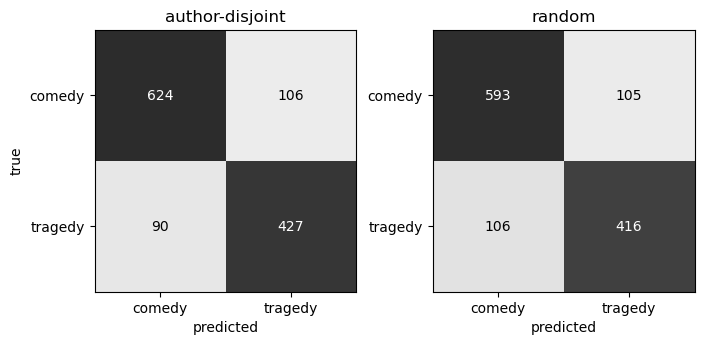

In [14]:
figure, axes = plt.subplots(1, 2, figsize=(8, 3.4))

for i in range(2):
    kind = ['author-disjoint', 'random'][i]
    table = matrices[kind]
    shares = table / table.sum(axis=1, keepdims=True)

    axes[i].imshow(shares, cmap='Greys', vmin=0, vmax=1)
    for a in range(2):
        for b in range(2):
            colour = 'white'
            if shares[a, b] < 0.5:
                colour = 'black'
            axes[i].text(b, a, table[a, b], ha='center', va='center', color=colour)

    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(GENRES)
    axes[i].set_yticks([0, 1])
    axes[i].set_yticklabels(GENRES)
    axes[i].set_xlabel('predicted')
    axes[i].set_title(kind)

axes[0].set_ylabel('true')
drama.save(figure, 'fig1_confusion.png')
plt.show()

## 3 · Ein kleines neuronales Netz

Gleiche Splits, gleiche Stücke, mehr Kapazität. Bei 409 Stücken bringt das nichts —
was selbst ein Ergebnis ist.

In [15]:
from sklearn.neural_network import MLPClassifier

import warnings
warnings.filterwarnings('ignore')

# The network gets shares instead of raw counts, and only the 500 commonest
# words. 3000 raw counts against ~280 training plays overfits immediately;
# this at least gives it a chance. x1000 because the shares are tiny numbers
# and the network trains badly on them otherwise.
shares = drama.to_shares(counts)[:, :500] * 1000
is_comedy = (genre == 'comedy').astype(int)

for seed in SEEDS:
    for kind, split in splitters:
        train, test = split(plays, seed=seed)

        network = MLPClassifier(hidden_layer_sizes=(16,), max_iter=500,
                                random_state=seed, early_stopping=True)
        network.fit(shares[train], is_comedy[train])
        guess = np.where(network.predict(shares[test]) == 1, 'comedy', 'tragedy')

        results.append({'model': 'small network',
                        'split': kind,
                        'seed': seed,
                        'baseline': drama.majority_share(genre[test]),
                        'accuracy': accuracy_score(genre[test], guess),
                        'macro f1': f1_score(genre[test], guess, average='macro')})

scores = pd.DataFrame(results)
scores['margin'] = scores['accuracy'] - scores['baseline']
scores.to_csv(drama.RESULTS + '/models.csv', index=False)

scores.groupby(['model', 'split'])[['accuracy', 'margin']].mean().round(3)

accuracy  margin
model         split                            
naive bayes   author-disjoint     0.843   0.257
              random              0.827   0.255
small network author-disjoint     0.792   0.206
              random              0.798   0.225

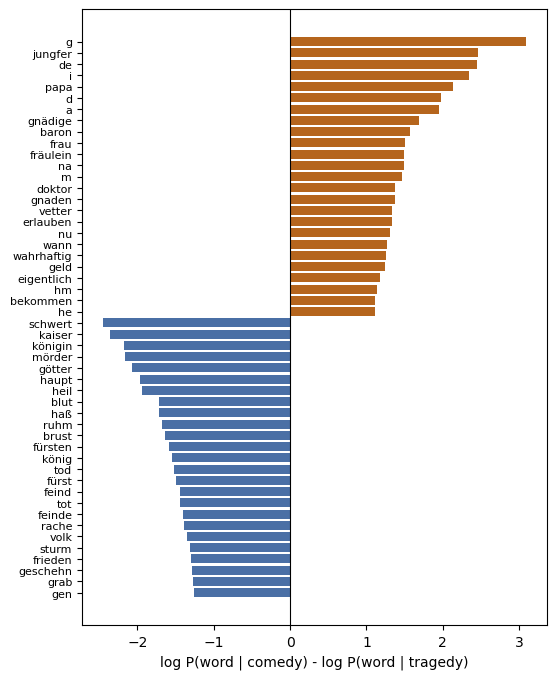

In [16]:
# fit on everything: this is description, not prediction, so no split needed
whole_corpus = MultinomialNB().fit(counts, genre)
lean = comedy_lean(whole_corpus)

# only reasonably common words - rare ones give unstable ratios
frequent = np.argsort(-counts.sum(axis=0))[:800]
ranked = frequent[np.argsort(lean[frequent])]

toward_tragedy = ranked[:25]
toward_comedy = ranked[-25:][::-1]

table = []
for i in toward_comedy:
    table.append({'word': vocabulary[i], 'lean': round(lean[i], 3), 'toward': 'comedy'})
for i in toward_tragedy:
    table.append({'word': vocabulary[i], 'lean': round(lean[i], 3), 'toward': 'tragedy'})
pd.DataFrame(table).to_csv(drama.RESULTS + '/words.csv', index=False, encoding='utf-8')

shown = list(toward_tragedy[::-1]) + list(toward_comedy[::-1])
names = []
values = []
bars = []
for i in shown:
    names.append(vocabulary[i])
    values.append(lean[i])
    if lean[i] < 0:
        bars.append(COLOUR['tragedy'])
    else:
        bars.append(COLOUR['comedy'])

figure, axis = plt.subplots(figsize=(6, 8))
axis.barh(np.arange(len(names)), values, color=bars)
axis.set_yticks(np.arange(len(names)))
axis.set_yticklabels(names, fontsize=8)
axis.axvline(0, color='black', lw=0.8)
axis.set_xlabel('log P(word | comedy) - log P(word | tragedy)')

drama.save(figure, 'fig3_words.png')
plt.show()

## 4 · Clustering ohne Labels

Zur Kontrolle jedes Mal auch gegen Zeit-Bins gleicher Grösse: findet k-Means Genre
oder nur Jahrhunderte?

In [17]:
import os
os.environ.setdefault('OMP_NUM_THREADS', '2')
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

# Relative frequencies turned into z-scores. This is the preprocessing Burrows'
# Delta uses in stylometry, so it is a defensible choice rather than one I
# invented: without the z-scores k-Means just follows "und" and "der", which
# are frequent everywhere and separate nothing.
features = drama.to_shares(counts)[:, :500]
features = (features - features.mean(axis=0)) / (features.std(axis=0) + 1e-12)

clusterings = {}
rows = []

for k in [2, 3, 4]:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=0)
    found = kmeans.fit(features).labels_
    clusterings[k] = found

    ranked_years = plays['year'].astype(float).rank(method='first')
    period = pd.qcut(ranked_years, k, labels=False)

    rows.append({'k': k,
                 'ari genre': adjusted_rand_score(genre, found),
                 'purity genre': drama.purity(found, genre),
                 'ari period': adjusted_rand_score(period, found),
                 'purity period': drama.purity(found, period.values)})

print('purity floor:', round(BASELINE, 3))
pd.DataFrame(rows).round(3).set_index('k')

purity floor: 0.589


,ari genre,purity genre,ari period,purity period
k,,,,
2,0.234,0.743,-0.001,0.518
3,0.213,0.795,0.035,0.462
4,0.198,0.814,0.068,0.413


In [18]:
two = clusterings[2]
print(pd.crosstab(pd.Series(two, name='cluster'), pd.Series(genre, name='genre')))
print()

for c in [0, 1]:
    inside = plays[two == c]
    biggest = inside['author'].value_counts()
    print('cluster', c)
    print('   plays      ', len(inside))
    print('   median year', int(inside['year'].median()))
    print('   biggest author', biggest.index[0], '(' + str(biggest.iloc[0]) + ')')

genre    comedy  tragedy
cluster                 
0           195       59
1            46      109

cluster 0
   plays       254
   median year 1813
   biggest author Kotzebue (13)
cluster 1
   plays       155
   median year 1818
   biggest author Grillparzer (12)


## 5 · Regression über die Zeit

Statt eines harten Labels ein fortlaufender Score je Stück. Die Polynome werden an
ungesehenen Daten beurteilt, nicht am eigenen Fit.

In [19]:
from sklearn.linear_model import LinearRegression

# score every play with a model that never saw it, then divide by its length
comedy_score = np.full(len(plays), np.nan)

# folds_by_author gives 5 author-disjoint folds, so every play ends up scored
# by a model that never read it or anything else by its author. Scoring plays
# with a model trained on them would just measure how well it memorised.
for train, test in drama.folds_by_author(plays, k=5, seed=0):
    fold_model = MultinomialNB().fit(counts[train], genre[train])
    lean = comedy_lean(fold_model)

    words_in_play = counts[test].sum(axis=1)
    words_in_play[words_in_play == 0] = 1
    comedy_score[test] = (counts[test] @ lean) / words_in_play

dated = plays.copy()
dated['score'] = comedy_score
dated = dated.dropna(subset=['score', 'year'])

century = (dated['year'].astype(float).values - 1800) / 100    # centred, else the cubic blows up
score = dated['score'].values

for g in GENRES:
    print('mean score', g, round(score[(dated['genre'] == g).values].mean(), 4))

mean score comedy 0.0834
mean score tragedy -0.0952


In [20]:
def fit_polynomial(degree, x, y):
    columns = []
    for p in range(degree + 1):
        columns.append(x ** p)
    return np.linalg.lstsq(np.column_stack(columns), y, rcond=None)[0]


def use_polynomial(weights, x):
    total = 0
    for p in range(len(weights)):
        total = total + weights[p] * x ** p
    return total


def r_squared(true, predicted):
    left_over = ((true - predicted) ** 2).sum()
    spread = ((true - true.mean()) ** 2).sum()
    return 1 - left_over / spread


rows = []
for degree in [1, 2, 3]:
    unseen = np.full(len(dated), np.nan)
    for train, test in drama.folds_by_author(dated, k=5, seed=1):
        weights = fit_polynomial(degree, century[train], score[train])
        unseen[test] = use_polynomial(weights, century[test])

    on_the_fit = use_polynomial(fit_polynomial(degree, century, score), century)
    rows.append({'degree': degree,
                 'r2 on the fit': r_squared(score, on_the_fit),
                 'r2 held out': r_squared(score, unseen)})

straight = fit_polynomial(1, century, score)
sklearn_line = LinearRegression().fit(century.reshape(-1, 1), score)
print('slope per century, mine   ', round(straight[1], 5))
print('slope per century, sklearn', round(sklearn_line.coef_[0], 5))

# and inside each genre, in case the trend is only the changing genre mix
for g in GENRES:
    pick = (dated['genre'] == g).values
    inside = fit_polynomial(1, century[pick], score[pick])
    print('   within', g, round(inside[1], 5))

pd.DataFrame(rows).round(4).set_index('degree')

slope per century, mine    0.0191
slope per century, sklearn 0.0191
   within comedy 0.02057
   within tragedy 0.0245


,r2 on the fit,r2 held out
degree,,
1,0.0110,-0.0048
2,0.0141,-0.0247
3,0.0265,-0.0328


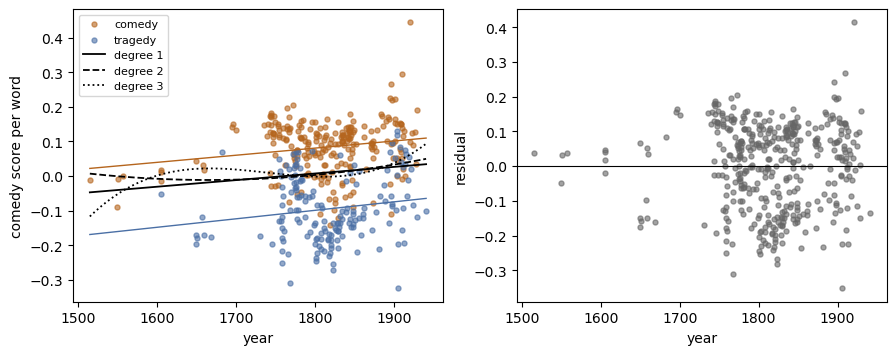

In [21]:
line = np.linspace(century.min(), century.max(), 200)
figure, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))

for g in GENRES:
    pick = (dated['genre'] == g).values
    axes[0].scatter(century[pick] * 100 + 1800, score[pick], s=13,
                    alpha=0.6, color=COLOUR[g], label=g)
    weights = fit_polynomial(1, century[pick], score[pick])
    axes[0].plot(line * 100 + 1800, use_polynomial(weights, line), color=COLOUR[g], lw=1)

for degree, style in [(1, '-'), (2, '--'), (3, ':')]:
    weights = fit_polynomial(degree, century, score)
    axes[0].plot(line * 100 + 1800, use_polynomial(weights, line), style,
                 color='black', lw=1.3, label='degree ' + str(degree))

axes[0].set_xlabel('year')
axes[0].set_ylabel('comedy score per word')
axes[0].legend(fontsize=8)

left_over = score - use_polynomial(straight, century)
axes[1].scatter(century * 100 + 1800, left_over, s=13, alpha=0.6, color='0.4')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_xlabel('year')
axes[1].set_ylabel('residual')

drama.save(figure, 'fig5_regression.png')
plt.show()

In [22]:
outliers = dated.copy()
outliers['residual'] = left_over
outliers = outliers.reindex(outliers['residual'].abs().sort_values(ascending=False).index)
outliers[['play', 'year', 'genre', 'residual']].head(8).round(3)

,play,year,genre,residual
47,bossdorf-de-rode-uennerrock,1921,comedy,0.414
97,gerhaeuser-der-moloch,1906,tragedy,-0.352
52,brawe-brutus,1768,tragedy,-0.310
31,beer-der-paria,1823,tragedy,-0.283
369,thoma-erster-klasse,1910,comedy,0.267
384,voss-faust,1823,tragedy,-0.267
339,schlegel-alarcos,1802,tragedy,-0.252
66,cronegk-codrus,1758,tragedy,-0.249


## 6 · Was benutzt der Klassifikator?

Das Modell absichtlich kaputt machen und schauen, was übrig bleibt. Verglichen wird
die margin über der jeweils eigenen Baseline, nicht die rohe Accuracy.

In [23]:
short_share = []
for text in plays['text']:
    tokens = drama.tokenize(text)
    short = 0
    for word in tokens:
        if len(word) <= 2:
            short = short + 1
    short_share.append(short / len(tokens))
short_share = np.array(short_share)

for g in GENRES:
    print('share of 1-2 letter words,', g, round(short_share[genre == g].mean(), 3))

dialect_heavy = plays.copy()
dialect_heavy['short'] = short_share
dialect_heavy.nlargest(10, 'short')[['play', 'genre', 'short']].round(3)

share of 1-2 letter words, comedy 0.106
share of 1-2 letter words, tragedy 0.093


,play,genre,short
47,bossdorf-de-rode-uennerrock,comedy,0.308
369,thoma-erster-klasse,comedy,0.260
318,rosenow-kater-lampe,comedy,0.216
11,anzengruber-der-gwissenswurm,comedy,0.213
274,malss-die-jungfern-koechinnen,comedy,0.199
319,ruederer-die-fahnenweihe,comedy,0.197
294,niebergall-datterich,comedy,0.194
368,thoma-die-medaille,comedy,0.185
12,anzengruber-die-kreuzelschreiber,comedy,0.179
358,sessa-unser-verkehr,comedy,0.178


In [24]:
commonest = np.argsort(-counts.sum(axis=0))[:100]

is_long_word = np.zeros(len(vocabulary), bool)
is_common = np.zeros(len(vocabulary), bool)
for i in range(len(vocabulary)):
    is_long_word[i] = len(vocabulary[i]) >= 3
is_common[commonest] = True

all_words = np.ones(len(vocabulary), bool)
all_plays = np.ones(len(plays), bool)
not_dialect = short_share < np.quantile(short_share, 0.9)

variants = {}
variants['everything'] = (all_words, all_plays)
variants['words 3+ letters'] = (is_long_word, all_plays)
variants['top 100 words only'] = (is_common, all_plays)
variants['top 100 removed'] = (~is_common, all_plays)
variants['dialect decile cut'] = (all_words, not_dialect)

rows = []
for name in variants:
    keep_words, keep_plays = variants[name]

    # with a smaller vocabulary 'top 100 removed' could leave nothing behind
    if keep_words.sum() == 0:
        print(name, '- no words left, skipped')
        continue

    subset = plays[keep_plays].reset_index(drop=True)
    subcounts = counts[keep_plays][:, keep_words]
    subgenre = genre[keep_plays]

    for seed in SEEDS:
        train, test = drama.split_by_author(subset, seed=seed)
        model = MultinomialNB().fit(subcounts[train], subgenre[train])
        predicted = model.predict(subcounts[test])

        rows.append({'variant': name,
                     'plays': keep_plays.sum(),
                     'words': keep_words.sum(),
                     'baseline': drama.majority_share(subgenre[test]),
                     'accuracy': (predicted == subgenre[test]).mean()})

ablation = pd.DataFrame(rows)
ablation['margin'] = ablation['accuracy'] - ablation['baseline']
ablation.to_csv(drama.RESULTS + '/ablation.csv', index=False)

summary = ablation.groupby('variant', sort=False).mean(numeric_only=True)
summary.round(3)

,plays,words,baseline,accuracy,margin
variant,,,,,
everything,409.0,3000.0,0.586,0.843,0.257
words 3+ letters,409.0,2955.0,0.586,0.834,0.248
top 100 words only,409.0,100.0,0.586,0.788,0.202
top 100 removed,409.0,2900.0,0.586,0.854,0.268
dialect decile cut,368.0,3000.0,0.558,0.791,0.233


Und der formale Verdacht: ist das alles nur Vers gegen Prosa?

In [25]:
# DraCor counts TEI <l> (verse lines) and <p> (prose paragraphs)
lines = meta.set_index('name')
verse = plays.copy()
verse['l'] = verse['play'].map(lines['numOfL']).astype(float)
verse['p'] = verse['play'].map(lines['numOfP']).astype(float)
verse = verse[(verse['l'] + verse['p']) > 0].reset_index(drop=True)
verse['verse share'] = verse['l'] / (verse['l'] + verse['p'])
verse_genre = verse['genre'].values

for g in GENRES:
    column = verse.loc[verse_genre == g, 'verse share']
    print(g)
    print('   mean  ', round(column.mean(), 3))
    print('   median', round(column.median(), 3))
    print('   over 90% verse:', round(100 * (column > 0.9).mean()), '%')

comedy
   mean   0.215
   median 0.008
   over 90% verse: 16 %
tragedy
   mean   0.537
   median 0.949
   over 90% verse: 51 %


In [26]:
# how far does that one number get on its own?
alone = []
floor = []
for seed in SEEDS:
    train, test = drama.split_by_author(verse, seed=seed)

    best_cut = 0
    best_hits = 0
    for cut in np.linspace(0, 1, 101):
        guess = np.where(verse['verse share'][train] > cut, 'tragedy', 'comedy')
        hits = (guess == verse_genre[train]).mean()
        if hits > best_hits:
            best_hits = hits
            best_cut = cut

    guess = np.where(verse['verse share'][test] > best_cut, 'tragedy', 'comedy')
    alone.append((guess == verse_genre[test]).mean())
    floor.append(drama.majority_share(verse_genre[test]))

print('verse share alone, margin:', round(np.mean(alone) - np.mean(floor), 3))

verse share alone, margin: 0.136


In [27]:
# count_with_words, not count_words: the same 3000-word list as above. If each
# subset built its own vocabulary the numbers would not be comparable.
verse_counts = drama.count_with_words(verse['text'].values, vocabulary)

subsets = {}
subsets['all plays'] = np.ones(len(verse), bool)
subsets['verse only'] = (verse['verse share'] > 0.7).values
subsets['prose only'] = (verse['verse share'] < 0.3).values

rows = []
for name in subsets:
    keep = subsets[name]
    subset = verse[keep].reset_index(drop=True)
    subcounts = verse_counts[keep]
    subgenre = verse_genre[keep]

    for seed in SEEDS:
        train, test = drama.split_by_author(subset, seed=seed)
        model = MultinomialNB().fit(subcounts[train], subgenre[train])
        predicted = model.predict(subcounts[test])

        rows.append({'subset': name,
                     'plays': keep.sum(),
                     'comedy': (subgenre == 'comedy').sum(),
                     'tragedy': (subgenre == 'tragedy').sum(),
                     'baseline': drama.majority_share(subgenre[test]),
                     'accuracy': (predicted == subgenre[test]).mean()})

inside = pd.DataFrame(rows)
inside['margin'] = inside['accuracy'] - inside['baseline']
inside.to_csv(drama.RESULTS + '/verse.csv', index=False)

by_form = inside.groupby('subset', sort=False).mean(numeric_only=True)
by_form.round(3)

,plays,comedy,tragedy,baseline,accuracy,margin
subset,,,,,,
all plays,409.0,241.0,168.0,0.586,0.843,0.257
verse only,131.0,44.0,87.0,0.682,0.928,0.246
prose only,264.0,188.0,76.0,0.697,0.843,0.146


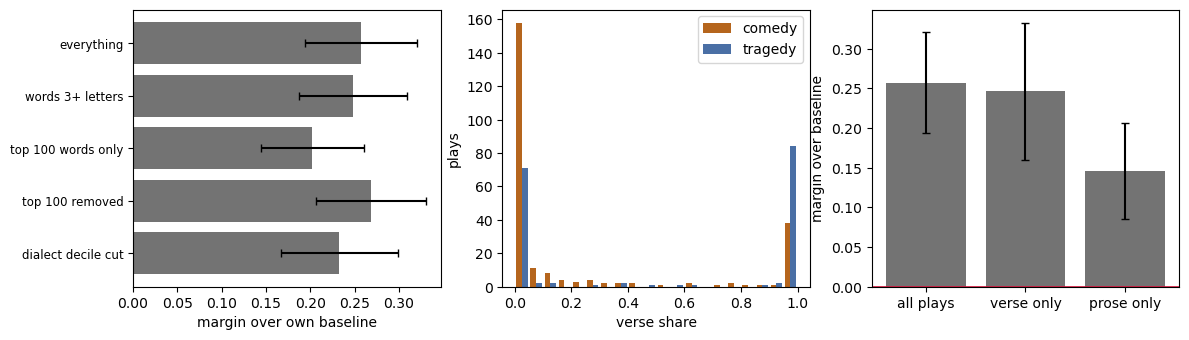

In [28]:
figure, axes = plt.subplots(1, 3, figsize=(13.5, 3.6))

names = list(variants)
heights = []
errors = []
for name in names:
    picked = ablation[ablation['variant'] == name]
    heights.append(picked['margin'].mean())
    errors.append(picked['margin'].std())

axes[0].barh(np.arange(len(names)), heights, xerr=errors, capsize=3, color='0.45')
axes[0].set_yticks(np.arange(len(names)))
axes[0].set_yticklabels(names, fontsize=8.5)
axes[0].invert_yaxis()
axes[0].axvline(0, color='crimson', lw=1.2)
axes[0].set_xlabel('margin over own baseline')

axes[1].hist([verse.loc[verse_genre == 'comedy', 'verse share'],
              verse.loc[verse_genre == 'tragedy', 'verse share']],
             bins=np.linspace(0, 1, 21),
             color=[COLOUR['comedy'], COLOUR['tragedy']], label=GENRES)
axes[1].set_xlabel('verse share')
axes[1].set_ylabel('plays')
axes[1].legend()

names = list(subsets)
heights = []
errors = []
for name in names:
    picked = inside[inside['subset'] == name]
    heights.append(picked['margin'].mean())
    errors.append(picked['margin'].std())

axes[2].bar(np.arange(len(names)), heights, yerr=errors, capsize=3, color='0.45')
axes[2].set_xticks(np.arange(len(names)))
axes[2].set_xticklabels(names)
axes[2].axhline(0, color='crimson', lw=1.2)
axes[2].set_ylabel('margin over baseline')

drama.save(figure, 'fig6_ablation.png')
plt.show()

## 7 · Ständeklausel

Die Wortliste in Abschnitt 3 sieht nach sozialem Stand aus: Hof gegen Haushalt. Das
lässt sich unabhängig vom Dialog prüfen, nämlich an den Rollennamen im Personen-
verzeichnis. Deutsche Rollennamen tragen den Stand im Namen.

In [29]:
NOBLE = ['kaiser', 'könig', 'prinz', 'fürst', 'herzog', 'graf',
         'baron', 'freiherr', 'marquis', 'ritter']
SERVANT = ['diener', 'magd', 'knecht', 'bauer', 'wirt', 'kellner', 'kutscher',
           'gärtner', 'schäfer', 'hirt', 'bote', 'amme', 'page', 'koch',
           'wächter', 'schuster', 'schneider', 'müller']


def rank_of(name):
    name = str(name).lower()
    for word in NOBLE:
        if word in name:
            return 'noble'
    for word in SERVANT:
        if word in name:
            return 'servant'
    return 'other'


# One request per play, so this is the slow cell: about ten minutes the first
# time. It saves every 50 plays and skips what it already has, so stopping it
# and starting again is safe.
people = drama.get_characters(plays)
people['rank'] = people['character'].map(rank_of)

print('characters:', len(people))
print(people['rank'].value_counts().to_string())
print()
print(people[people['rank'] == 'noble']['character'].value_counts().head(8).to_string())

cast lists still to fetch: 0
characters: 8589
rank
other      7722
servant     465
noble       402

character
König         11
Baron          8
Der Graf       6
Königin        6
Ritter         4
Graf           4
Herzog         4
Ein Ritter     4


In [30]:
# per play: what share of the cast is noble, what share is servant
noble_share = []
servant_share = []

for play in plays['play']:
    cast = people[people['play'] == play]
    if len(cast) == 0:
        noble_share.append(np.nan)
        servant_share.append(np.nan)
        continue
    noble_share.append((cast['rank'] == 'noble').mean())
    servant_share.append((cast['rank'] == 'servant').mean())

ranked = plays.copy()
ranked['noble'] = noble_share
ranked['servant'] = servant_share
ranked = ranked.dropna(subset=['noble'])

print('plays with a cast list:', len(ranked))
print()
for g in GENRES:
    rows = ranked[ranked['genre'] == g]
    print(g)
    print('   noble share  ', round(rows['noble'].mean(), 3))
    print('   servant share', round(rows['servant'].mean(), 3))
    print('   plays with any noble role:', round(100 * (rows['noble'] > 0).mean()), '%')

plays with a cast list: 409

comedy
   noble share   0.045
   servant share 0.047
   plays with any noble role: 30 %
tragedy
   noble share   0.041
   servant share 0.052
   plays with any noble role: 46 %


In [31]:
# does cast rank alone separate the genres, without looking at the dialogue at all?
alone = []
floor = []
for seed in SEEDS:
    train, test = drama.split_by_author(ranked, seed=seed)
    rank_gap = (ranked['noble'] - ranked['servant']).values

    best_cut = 0
    best_hits = 0
    for cut in np.linspace(-1, 1, 201):
        guess = np.where(rank_gap[train] > cut, 'tragedy', 'comedy')
        hits = (guess == ranked['genre'].values[train]).mean()
        if hits > best_hits:
            best_hits = hits
            best_cut = cut

    guess = np.where(rank_gap[test] > best_cut, 'tragedy', 'comedy')
    alone.append((guess == ranked['genre'].values[test]).mean())
    floor.append(drama.majority_share(ranked['genre'].values[test]))

print('cast rank alone, accuracy:', round(np.mean(alone), 3))
print('baseline                 :', round(np.mean(floor), 3))
print('margin                   :', round(np.mean(alone) - np.mean(floor), 3))

ranked[['play', 'genre', 'noble', 'servant']].to_csv(
    drama.RESULTS + '/rank.csv', index=False, encoding='utf-8')

cast rank alone, accuracy: 0.557
baseline                 : 0.586
margin                   : -0.029


## 8 · Wo liegt das Schauspiel?

358 Stücke tragen gar kein Genre, die meisten davon Schauspiele. Das Schauspiel ist
historisch die Gattung zwischen Komödie und Tragödie. Wenn die gelernte Achse echt
ist, sollten diese Stücke in der Mitte landen.

In [32]:
unlabelled = catalog[catalog['dracor'].isna()]
print('plays without a genre:', len(unlabelled))
print(drama.download_texts(unlabelled))

others = drama.read_texts(unlabelled)
print('with text:', len(others))

plays without a genre: 365
{'downloaded': 0, 'already had': 365, 'failed': 0}
with text: 365


In [33]:
# train on everything labelled, then score the unlabelled plays on the same words
whole_corpus = MultinomialNB().fit(counts, genre)
lean = comedy_lean(whole_corpus)

# again the training vocabulary, not a fresh one - these plays have to be
# measured on exactly the same words the model was trained on
other_counts = drama.count_with_words(others['text'].values, vocabulary)
other_length = other_counts.sum(axis=1)
other_length[other_length == 0] = 1
others['score'] = (other_counts @ lean) / other_length

print('median score')
for g in GENRES:
    print('  ', g, round(np.median(comedy_score[genre == g]), 4))
print('   unlabelled', round(others['score'].median(), 4))

median score
   comedy 0.0977
   tragedy -0.1108
   unlabelled -0.0224


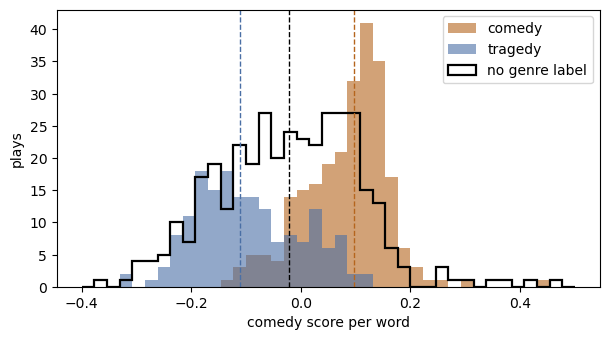

In [34]:
figure, axis = plt.subplots(figsize=(7, 3.6))

for g in GENRES:
    axis.hist(comedy_score[genre == g], bins=np.linspace(-0.4, 0.5, 40),
              alpha=0.6, color=COLOUR[g], label=g)
axis.hist(others['score'], bins=np.linspace(-0.4, 0.5, 40),
          histtype='step', lw=1.6, color='black', label='no genre label')

axis.axvline(np.median(comedy_score[genre == 'tragedy']), color=COLOUR['tragedy'], lw=1, ls='--')
axis.axvline(np.median(comedy_score[genre == 'comedy']), color=COLOUR['comedy'], lw=1, ls='--')
axis.axvline(others['score'].median(), color='black', lw=1, ls='--')
axis.set_xlabel('comedy score per word')
axis.set_ylabel('plays')
axis.legend()

drama.save(figure, 'fig8_schauspiel.png')
plt.show()

others[['play', 'author', 'year', 'subtitle', 'score']].to_csv(
    drama.RESULTS + '/unlabelled.csv', index=False, encoding='utf-8')

In [35]:
# the subtitles at each end of the axis
sorted_others = others.sort_values('score')
print('most tragedy-like:')
print(sorted_others[['play', 'subtitle']].head(6).to_string(index=False))
print()
print('most comedy-like:')
print(sorted_others[['play', 'subtitle']].tail(6).to_string(index=False))

most tragedy-like:
                              play                                        subtitle
anonym-das-ehrenmaal-des-patrioten                                       Singspiel
                       brandes-ino                                   Ein Melodrama
                     gehe-jessonda                           Oper in drei Aufzügen
    raupach-agnes-von-hohenstaufen Große historisch-romantische Oper in 3 Aufzügen
   mosenthal-die-koenigin-von-saba                           Oper in vier Aufzügen
                   chezy-euryanthe               Romantische Oper in drei Aufzügen

most comedy-like:
                                        play                                       subtitle
              hauptmann-carl-ephraims-breite                       Schauspiel in fünf Akten
                            kobell-der-roaga                                               
ganghofer-der-herrgottschnitzer-von-ammergau                  Volksschauspiel in 5 Aufzügen
             